# Gestione delle cartelle/Definizione dei Path

In [1]:
N_FEATURES = 150
NUM_SAMPLES = 100000
NUM_CLUSTER = 150

In [2]:
# Importiamo le librerie necessarie per navigare nelle cartelle
import os
import cv2 # OpenCV per leggere le immagini
import matplotlib.pyplot as plt # Per mostrare le immagini a schermo
import numpy as np
from sklearn.cluster import KMeans
import joblib # Libreria per salvare modelli e array su file
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

from src.extract_features import read_split

In [3]:
def generate_dense_keypoints(image_shape, step_size=15, scales=[10, 20]):
    keypoints = []
    rows, cols = image_shape
    # Griglia spaziale
    for y in range(0, rows, step_size):
        for x in range(0, cols, step_size):
            # Iterazione sullo scale-space
            for size in scales:
                kp = cv2.KeyPoint(float(x), float(y), float(size))
                keypoints.append(kp)
    return keypoints

Trovate 1500 immagini di TRAINING.
Trovate 2985 immagini di TEST.
Classi: ['Bedroom', 'Coast', 'Forest', 'Highway', 'Industrial', 'InsideCity', 'Kitchen', 'LivingRoom', 'Mountain', 'Office', 'OpenCountry', 'Store', 'Street', 'Suburb', 'TallBuilding']


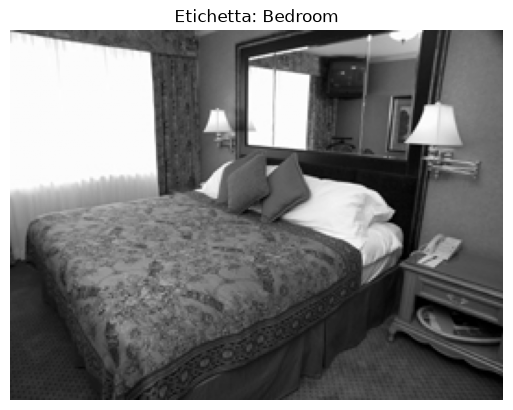

In [4]:
from pathlib import Path

# Le cartelle del dataset sono relative alla directory del progetto.
percorso_train = Path("dataset") / "train"
percorso_test = Path("dataset") / "test"

# read_split restituisce: percorsi delle immagini, indici numerici, nomi delle classi.
train_paths, train_label_ids, classi = read_split(percorso_train)
test_paths, test_label_ids, classi_test = read_split(percorso_test)

# Verifichiamo che train e test abbiano lo stesso ordine delle classi.
if classi != classi_test:
    raise ValueError(
        f"Le classi di train e test non corrispondono: {classi} != {classi_test}"
    )

# Il resto del notebook usa i nomi delle classi come etichette.
train_labels = np.array([classi[label_id] for label_id in train_label_ids])
test_labels = np.array([classi[label_id] for label_id in test_label_ids])

print(f"Trovate {len(train_paths)} immagini di TRAINING.")
print(f"Trovate {len(test_paths)} immagini di TEST.")
print(f"Classi: {classi}")

# Mostriamo la prima immagine per verificare percorso ed etichetta.
if train_paths:
    prima_immagine = cv2.imread(str(train_paths[0]), cv2.IMREAD_GRAYSCALE)
    if prima_immagine is None:
        raise ValueError(f"Impossibile leggere l'immagine: {train_paths[0]}")

    plt.imshow(prima_immagine, cmap="gray")
    plt.title(f"Etichetta: {train_labels[0]}")
    plt.axis("off")
    plt.show()
else:
    print("ERRORE: non sono state trovate immagini in dataset/train.")

In [5]:
def calcola_dimensione_media_immagini(image_paths):
    """Calcola altezza, larghezza e numero medio di pixel delle immagini."""
    heights = []
    widths = []
    unreadable_images = []

    for image_path in image_paths:
        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            unreadable_images.append(str(image_path))
            continue

        height, width = image.shape
        heights.append(height)
        widths.append(width)

    if not heights:
        raise ValueError("Nessuna immagine leggibile nel percorso indicato.")

    mean_height = np.mean(heights)
    mean_width = np.mean(widths)
    mean_pixels = np.mean(np.multiply(heights, widths))

    return {
        "mean_height": mean_height,
        "mean_width": mean_width,
        "mean_pixels": mean_pixels,
        "num_images": len(heights),
        "unreadable_images": unreadable_images,
    }


train_image_size = calcola_dimensione_media_immagini(train_paths)
test_image_size = calcola_dimensione_media_immagini(test_paths)

for dataset_name, image_size in (
    ("TRAIN", train_image_size),
    ("TEST", test_image_size),
):
    print(f"{dataset_name}:")
    print(f"  Immagini analizzate: {image_size['num_images']}")
    print(f"  Altezza media: {image_size['mean_height']:.2f} pixel")
    print(f"  Larghezza media: {image_size['mean_width']:.2f} pixel")
    print(f"  Pixel medi per immagine: {image_size['mean_pixels']:.2f}")
    print(f"  Immagini non leggibili: {len(image_size['unreadable_images'])}")

TRAIN:
  Immagini analizzate: 1500
  Altezza media: 242.76 pixel
  Larghezza media: 275.97 pixel
  Pixel medi per immagine: 66396.96
  Immagini non leggibili: 0
TEST:
  Immagini analizzate: 2985
  Altezza media: 246.03 pixel
  Larghezza media: 271.64 pixel
  Pixel medi per immagine: 66294.07
  Immagini non leggibili: 0


# Inizializzazione SIFT

In [6]:
sift = cv2.SIFT_create(nfeatures=N_FEATURES, contrastThreshold = 0.01)

all_keypoints = []
all_descriptors = []
keypoint_counts = []
keypoint_labels = []

# ... all_keypoints = [] etc.
for image_path, label in zip(train_paths, train_labels):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Impossibile leggere l'immagine: {image_path}")

    # Generiamo i keypoint sulla griglia e calcoliamo i descrittori
    dense_keypoints = generate_dense_keypoints(image.shape, step_size=15, scales=[10, 20])
    keypoints, descriptors = sift.compute(image, dense_keypoints)
    
    keypoint_counts.append(len(keypoints))
    # ... (resto degli append invariato)
    keypoint_labels.append(label)

    if descriptors is not None:
        all_descriptors.append(descriptors)
        all_keypoints.append(keypoints)

keypoint_counts = np.array(keypoint_counts, dtype=np.int32)
keypoint_labels = np.array(keypoint_labels)

print(f"Immagini analizzate: {len(keypoint_counts)}")
print(f"Keypoint totali: {keypoint_counts.sum()}")

Immagini analizzate: 1500
Keypoint totali: 955426


# TEST

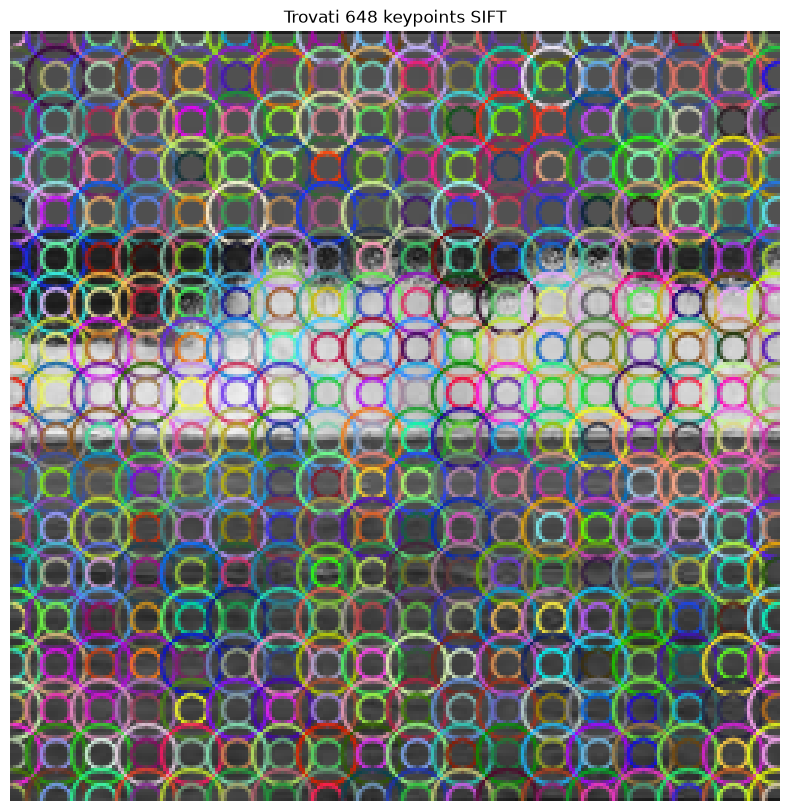

In [7]:
# 1. Prendiamo la prima immagine della lista
immagine_test = cv2.imread(train_paths[150], cv2.IMREAD_GRAYSCALE)

# 2. Estraiamo keypoint e descrittori solo per lei
keypoints_test = all_keypoints[150]
descriptors_test = all_descriptors[150]

# 3. Disegniamo i keypoint sopra l'immagine
# L'opzione DRAW_RICH_KEYPOINTS disegna i cerchi con la dimensione e l'inclinazione (l'orientamento)
immagine_con_kp = cv2.drawKeypoints(
    immagine_test,
    keypoints_test,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# 4. Mostriamo il risultato
plt.figure(figsize=(10, 10)) # Facciamo un'immagine bella grande
plt.imshow(immagine_con_kp, cmap='gray')
plt.title(f"Trovati {len(keypoints_test)} keypoints SIFT")
plt.axis('off')
plt.show()

Bedroom: media=594.46, deviazione standard=70.70, varianza=4999.03
Coast: media=648.00, deviazione standard=0.00, varianza=0.00
Forest: media=648.00, deviazione standard=0.00, varianza=0.00
Highway: media=648.00, deviazione standard=0.00, varianza=0.00
Industrial: media=627.60, deviazione standard=64.99, varianza=4224.24
InsideCity: media=648.00, deviazione standard=0.00, varianza=0.00
Kitchen: media=615.00, deviazione standard=45.40, varianza=2061.00
LivingRoom: media=612.00, deviazione standard=46.09, varianza=2124.00
Mountain: media=648.00, deviazione standard=0.00, varianza=0.00
Office: media=647.70, deviazione standard=59.71, varianza=3565.71
OpenCountry: media=648.00, deviazione standard=0.00, varianza=0.00
Store: media=613.50, deviazione standard=48.44, varianza=2346.75
Street: media=648.00, deviazione standard=0.00, varianza=0.00
Suburb: media=660.00, deviazione standard=0.00, varianza=0.00
TallBuilding: media=648.00, deviazione standard=0.00, varianza=0.00


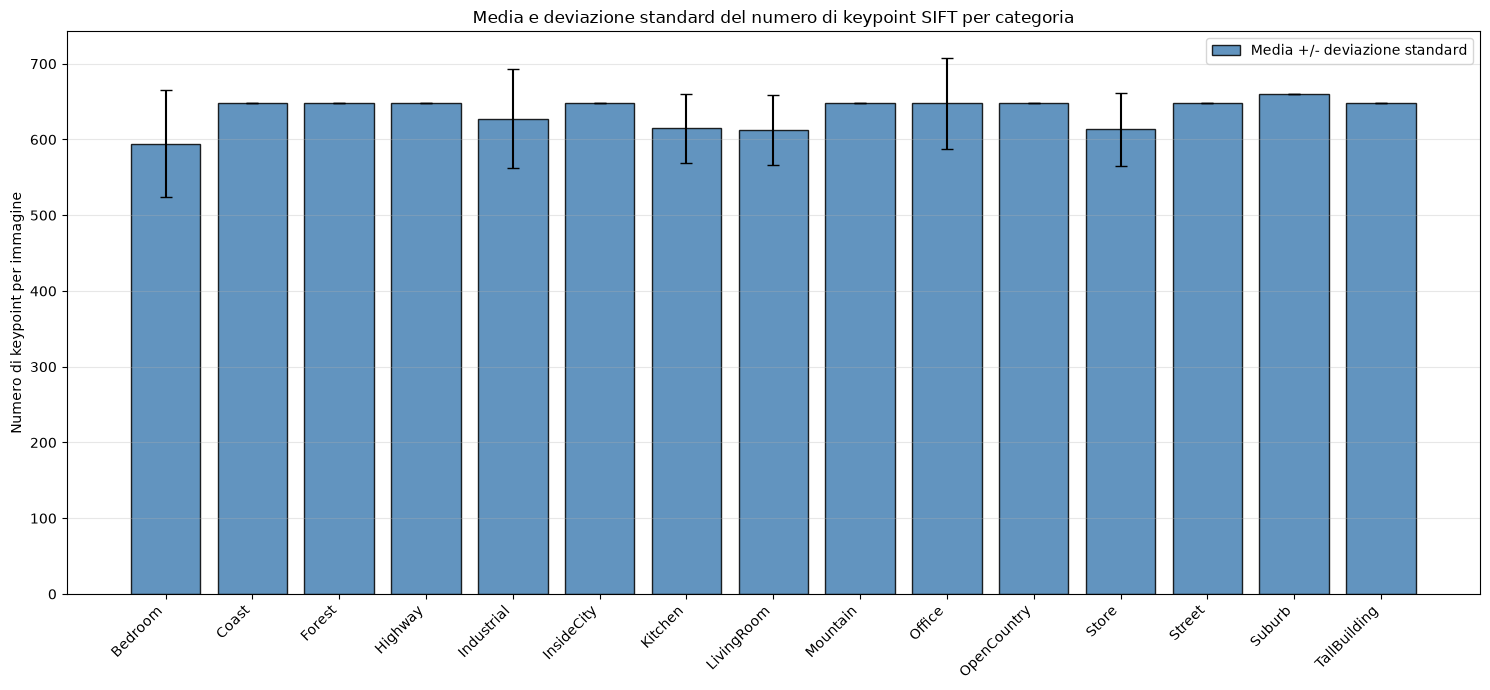

In [8]:
# Statistiche del numero di keypoint per ogni categoria.
mean_keypoints = []
variance_keypoints = []

for class_name in classi:
    class_counts = keypoint_counts[keypoint_labels == class_name]
    mean_keypoints.append(np.mean(class_counts))
    variance_keypoints.append(np.var(class_counts))

mean_keypoints = np.array(mean_keypoints)
variance_keypoints = np.array(variance_keypoints)
std_keypoints = np.sqrt(variance_keypoints)

statistics_keypoints = {
    class_name: {
        "mean": mean,
        "std": std,
        "variance": variance,
    }
    for class_name, mean, std, variance in zip(
        classi, mean_keypoints, std_keypoints, variance_keypoints
    )
}

for class_name, statistics in statistics_keypoints.items():
    print(
        f"{class_name}: media={statistics['mean']:.2f}, "
        f"deviazione standard={statistics['std']:.2f}, "
        f"varianza={statistics['variance']:.2f}"
    )

positions = np.arange(len(classi))
plt.figure(figsize=(15, 7))
plt.bar(
    positions,
    mean_keypoints,
    yerr=std_keypoints,
    capsize=4,
    color="steelblue",
    edgecolor="black",
    alpha=0.85,
    label="Media +/- deviazione standard",
)

plt.xticks(positions, classi, rotation=45, ha="right")
plt.ylabel("Numero di keypoint per immagine")
plt.title("Media e deviazione standard del numero di keypoint SIFT per categoria")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:

# 1. Stack all descriptor arrays vertically into a single massive matrix
stacked_descriptors = np.vstack(all_descriptors)

total_descriptors = stacked_descriptors.shape[0]
print(f"Total descriptors extracted: {total_descriptors}")

# 2. Set the target number of samples (10K to 100K as per assignment)
num_samples = NUM_SAMPLES

# 3. Perform random sampling
if total_descriptors > num_samples:
    print(f"Sampling {num_samples} descriptors randomly...")

    # Generate random row indices without replacement
    random_indices = np.random.choice(total_descriptors, num_samples, replace=False)

    # Filter the original matrix using the random indices
    sampled_descriptors = stacked_descriptors[random_indices, :]

else:
    print("Under the maximum limit, keeping all descriptors.")
    sampled_descriptors = stacked_descriptors

# Final verification (should output (100000, 128))
print(f"Ready for K-Means! Final array shape: {sampled_descriptors.shape}")

Total descriptors extracted: 955426
Sampling 100000 descriptors randomly...
Ready for K-Means! Final array shape: (100000, 128)


In [10]:
# 1. Definiamo il numero di cluster (le nostre visual words)
# Il prof consiglia di sperimentare, partiamo da 100
num_clusters = NUM_CLUSTER

print(f"Inizio addestramento K-Means con k={num_clusters} (potrebbe volerci qualche minuto)...")
start_time = time.time()

# 2. Inizializziamo l'algoritmo K-Means
# random_state=42 garantisce che se lo rieseguite domani, vi darà gli stessi identici cluster
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)

# 3. Addestriamo il modello sui nostri dati campionati
kmeans.fit(sampled_descriptors)

end_time = time.time()
print(f"K-Means completato in {(end_time - start_time) / 60:.2f} minuti.")

# 4. Estraiamo i centroidi (il nostro vero e proprio vocabolario)
# Sarà una matrice di forma (num_cluster, 128)
visual_vocabulary = kmeans.cluster_centers_
print(f"Forma del vocabolario visivo: {visual_vocabulary.shape}")

# 5. SALVATAGGIO PER IL FUTURO (Fondamentale!)
# Salviamo il modello direttamente nella vostra cartella su Drive così non lo perdete
#percorso_salvataggio = os.path.join(percorso_base, 'kmeans_vocabulary.pkl')
#joblib.dump(kmeans, percorso_salvataggio)
#print(f"Modello K-Means salvato con successo in: {percorso_salvataggio}")

Inizio addestramento K-Means con k=150 (potrebbe volerci qualche minuto)...
K-Means completato in 1.76 minuti.
Forma del vocabolario visivo: (150, 128)


In [ ]:
import cv2

import numpy as np

from scipy.spatial.distance import cdist
 
def compute_soft_normalized_histogram(image_path, sift_detector, kmeans_model, beta=0.001):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None

    # 1. Generazione keypoints dense ed estrazione descrittori SIFT
    dense_keypoints = generate_dense_keypoints(image.shape, step_size=15, scales=[10, 20])
    _, descriptors = sift_detector.compute(image, dense_keypoints)
    num_clusters = kmeans_model.n_clusters
    # Gestione di sicurezza in assenza di descrittori
    if descriptors is None or len(descriptors) == 0:
        return np.zeros(num_clusters)
    # 2. Recupero dei centroidi (vocabolario visivo) dal modello KMeans
    centroids = kmeans_model.cluster_centers_
    # 3. Calcolo della distanza euclidea al quadrato tra tutti i descrittori e i centroidi
    # Risultato: matrice di forma (N_descrittori, K_cluster)
    distances_sq = cdist(descriptors, centroids, metric='sqeuclidean')
    # 4. Applicazione del Kernel Gaussiano (Soft Weighting)
    weights = np.exp(-beta * distances_sq)
    # 5. Normalizzazione per riga: ogni descrittore distribuisce una massa totale pari a 1.0
    row_sums = np.sum(weights, axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0  # Protezione da underflow numerico
    normalized_weights = weights / row_sums
    # 6. Accumulo dei contributi per formare l'istogramma grezzo dell'immagine
    histogram = np.sum(normalized_weights, axis=0)
    # 7. Normalizzazione finale dell'istogramma dell'immagine (Somma = 1.0)
    total_mass = np.sum(histogram)
    if total_mass > 0:
        normalized_histogram = histogram / total_mass
    else:
        normalized_histogram = histogram
    return normalized_histogram
 

In [29]:
def compute_normalized_histogram(image_path, sift_detector, kmeans_model):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None

    # Mappatura su griglia al posto del detector
    dense_keypoints = generate_dense_keypoints(image.shape, step_size=15, scales=[10, 20])
    _, descriptors = sift_detector.compute(image, dense_keypoints)

    num_clusters = kmeans_model.n_clusters
    # ... (il resto dell'assegnazione visual words e np.histogram rimane identico)[cite: 1]

    # Gestione sicurezza: se l'immagine è troppo piatta e non trova keypoints
    if descriptors is None or len(descriptors) == 0:
        return np.zeros(num_clusters)

    # 2. Assegnazione a quale cluster appartiene ciascun descrittore
    # predict() restituisce un array di interi (es. [12, 45, 3, 12, ...])
    visual_words = kmeans_model.predict(descriptors)

    # 3. Creazione dell'istogramma grezzo (conteggi per ogni cluster)
    # np.histogram conta quanti elementi finiscono in ciascun "bin" (da 0 a num_clusters)
    histogram, _ = np.histogram(visual_words, bins=num_clusters, range=(0, num_clusters))

    # 4. Normalizzazione (la somma totale deve fare 1.0)
    total_descriptors = np.sum(histogram)
    if total_descriptors > 0:
        normalized_histogram = histogram / total_descriptors
    else:
        normalized_histogram = histogram

    return normalized_histogram

# --- APPLICHIAMO A TUTTO IL TRAINING SET ---
print("Generazione degli istogrammi per il training set...")

X_train = []
y_train = []

for path, label in zip(train_paths, train_labels):
    hist = compute_soft_normalized_histogram(path, sift, kmeans)
    if hist is not None:
        X_train.append(hist)
        y_train.append(label)

# Convertiamo in matrici NumPy definitive pronte per il Machine Learning
X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"Fatto! Matrice X_train creata con forma: {X_train.shape}")
print(f"Array y_train delle etichette creato con forma: {y_train.shape}")

Generazione degli istogrammi per il training set...
Fatto! Matrice X_train creata con forma: (1500, 150)
Array y_train delle etichette creato con forma: (1500,)


In [30]:
print("Generazione degli istogrammi per il TEST set...")

X_test = []
y_test = []

for path, label in zip(test_paths, test_labels):
    # Usiamo lo stesso SIFT e lo stesso vocabolario (kmeans) addestrato sul training!
    hist = compute_soft_normalized_histogram(path, sift, kmeans)
    if hist is not None:
        X_test.append(hist)
        y_test.append(label)

X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"Fatto! Matrice X_test creata con forma: {X_test.shape}")

Generazione degli istogrammi per il TEST set...
Fatto! Matrice X_test creata con forma: (2985, 150)


Addestramento del Nearest Neighbor in corso...
Calcolo delle previsioni sul test set...

--- ACCURATEZZA NEAREST NEIGHBOR: 55.88% ---


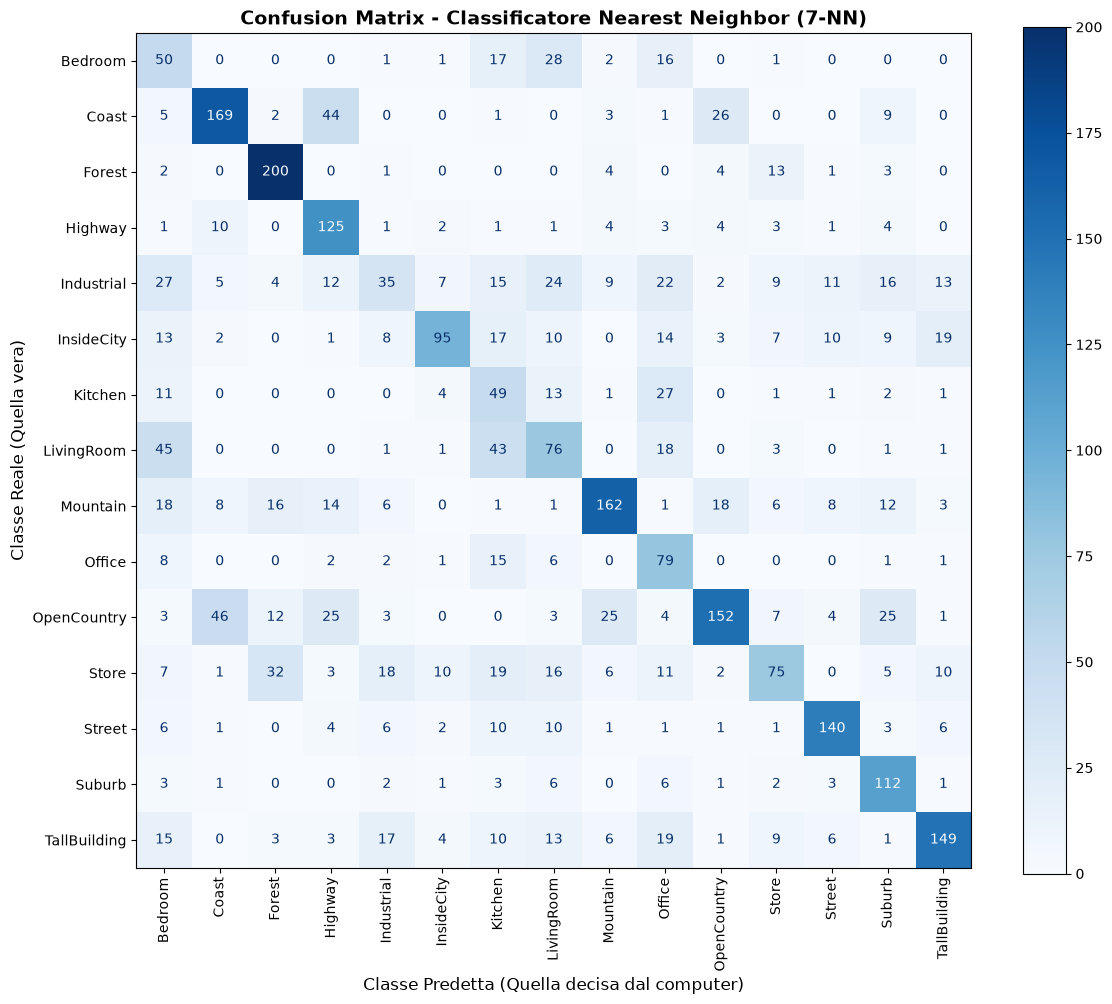

In [31]:
# 1. Inizializziamo il Nearest Neighbor
# n_neighbors=1 significa che guardiamo solo il vicino più stretto assoluto
nn_classifier = KNeighborsClassifier(n_neighbors=7, metric='euclidean')

# 2. Addestramento (per il KNN significa semplicemente "memorizzare" il training set)
print("Addestramento del Nearest Neighbor in corso...")
nn_classifier.fit(X_train, y_train)

# 3. Facciamo le previsioni sul test set!
print("Calcolo delle previsioni sul test set...")
y_pred_nn = nn_classifier.predict(X_test)

# Calcoliamo l'accuratezza generale (giusto per avere un numero riassuntivo)
accuracy_nn = accuracy_score(y_test, y_pred_nn)
print(f"\n--- ACCURATEZZA NEAREST NEIGHBOR: {accuracy_nn * 100:.2f}% ---")

# 4. Creazione della Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nn, labels=classi)

# 5. Visualizzazione bellissima della matrice
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classi)

# Usiamo una mappa di colori blu ('Blues')
disp.plot(ax=ax, cmap='Blues', xticks_rotation='vertical', values_format='d')

plt.title("Confusion Matrix - Classificatore Nearest Neighbor (7-NN)", fontsize=14, fontweight='bold')
plt.xlabel("Classe Predetta (Quella decisa dal computer)", fontsize=12)
plt.ylabel("Classe Reale (Quella vera)", fontsize=12)
plt.tight_layout()
plt.show()


--- PUNTO 4 & 5: ADDESTRAMENTO E VALUTAZIONE SVM (One-vs-Rest) ---
Addestramento della SVM in corso...
SVM addestrata in 0.29 secondi.
Calcolo degli output a valori reali (decision scores)...

--- ACCURATEZZA SVM: 47.50% ---


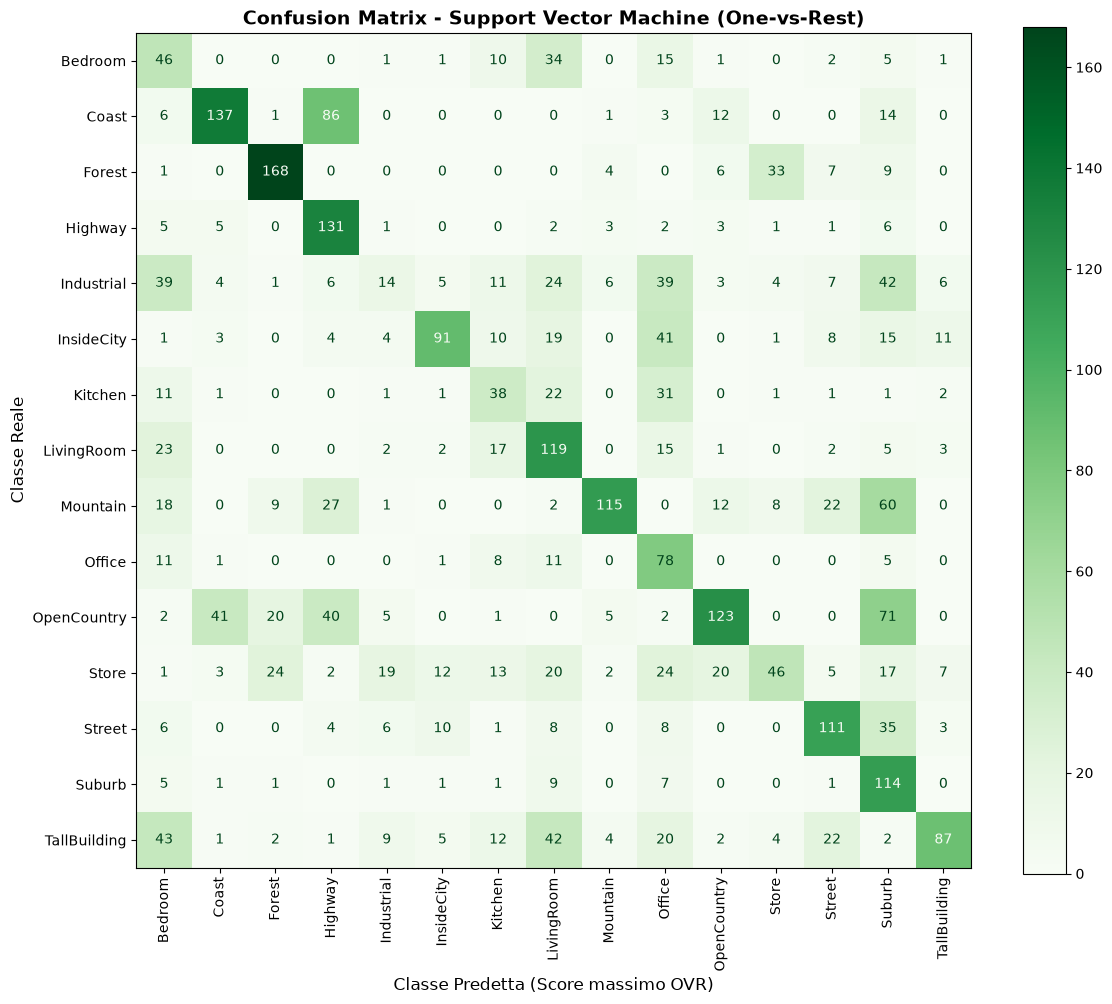

In [32]:
from sklearn.svm import SVC
import numpy as np
import time
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\n--- PUNTO 4 & 5: ADDESTRAMENTO E VALUTAZIONE SVM (One-vs-Rest) ---")

# --- PUNTO 4: Train a multiclass linear SVM (One-vs-Rest) ---
# kernel='linear' rispetta la richiesta "linear Support Vector Machine"
# decision_function_shape='ovr' forza l'approccio One-vs-Rest (15 classificatori)
svm_classifier = SVC(kernel='linear', decision_function_shape='ovr', random_state=42)

print("Addestramento della SVM in corso...")
start_time_svm = time.time()
svm_classifier.fit(X_train, y_train)
print(f"SVM addestrata in {(time.time() - start_time_svm):.2f} secondi.")

# --- PUNTO 5: Evaluate the multiclass SVM (Manualmente) ---
print("Calcolo degli output a valori reali (decision scores)...")

# 5.1: compute the real-valued output of each of the SVMs
# Questa funzione restituisce una matrice dove ogni riga ha 15 punteggi
decision_scores = svm_classifier.decision_function(X_test)

# 5.2: assign to the image the class corresponding to the greatest real-valued output
# np.argmax(..., axis=1) trova in automatico la colonna con il punteggio più alto per ogni riga
predicted_indices = np.argmax(decision_scores, axis=1)

# Riconvertiamo gli indici (da 0 a 14) nei nomi testuali delle classi (es. 'Kitchen')
# svm_classifier.classes_ contiene i nomi originali nell'ordine in cui li ha imparati
y_pred_svm = svm_classifier.classes_[predicted_indices]

# Calcoliamo l'accuratezza finale
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"\n--- ACCURATEZZA SVM: {accuracy_svm * 100:.2f}% ---")

# 5.3: repeat for all the test images and build a confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=classi)

# --- VISUALIZZAZIONE DELLA MATRICE DI CONFUSIONE ---
fig, ax = plt.subplots(figsize=(12, 10))
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=classi)

# Usiamo una mappa di colori verde ('Greens') per distinguerla da quella blu del KNN
disp_svm.plot(ax=ax, cmap='Greens', xticks_rotation='vertical', values_format='d')

plt.title("Confusion Matrix - Support Vector Machine (One-vs-Rest)", fontsize=14, fontweight='bold')
plt.xlabel("Classe Predetta (Score massimo OVR)", fontsize=12)
plt.ylabel("Classe Reale", fontsize=12)
plt.tight_layout()
plt.show()

Addestramento SVM con Kernel Gaussiano in corso...
Addestramento completato!
Valutazione sul test set...
Accuratezza della SVM Gaussiana: 67.64%


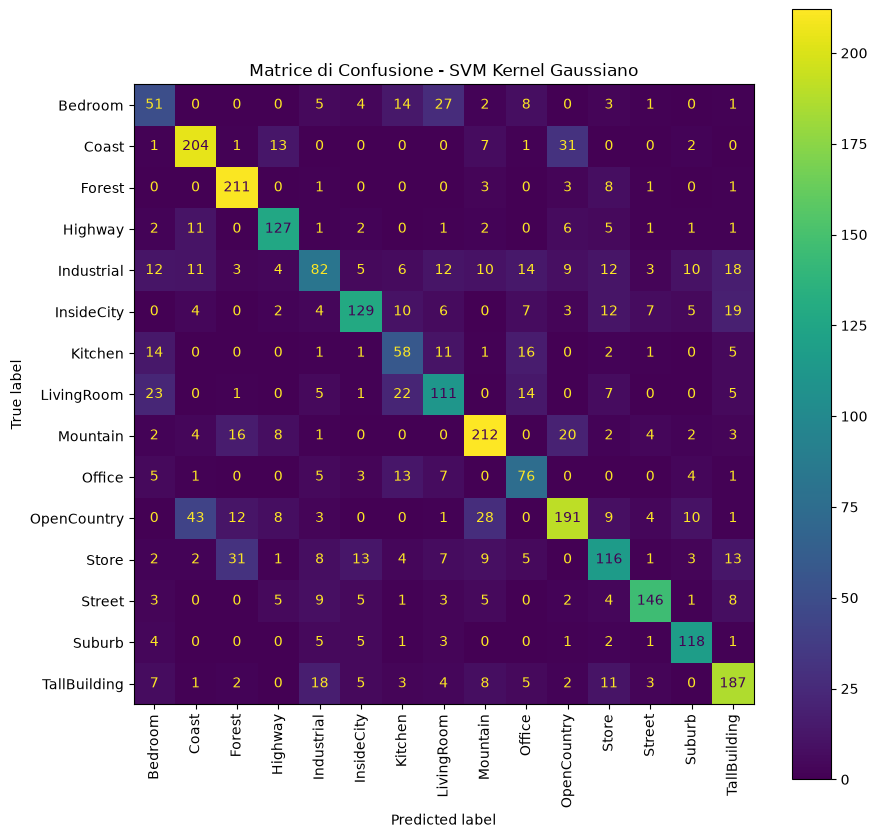

In [33]:
# --- ADDESTRAMENTO SVM CON KERNEL GAUSSIANO (RBF) ---
print("Addestramento SVM con Kernel Gaussiano in corso...")

# Inizializziamo il classificatore SVC con kernel RBF (gaussiano)
# C è il parametro di regolarizzazione (puoi regolarlo es. 1.0, 10.0)
# gamma definisce l'ampiezza della gaussiana ('scale' o 'auto' sono ottimi punti di partenza)
svm_gaussiana = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# Alleniamo il modello sui dati di training
svm_gaussiana.fit(X_train, y_train)

print("Addestramento completato!")

# --- VALUTAZIONE SUL TEST SET ---
print("Valutazione sul test set...")
y_pred = svm_gaussiana.predict(X_test)

# Calcoliamo l'accuratezza e stampiamo la matrice di confusione
acc = accuracy_score(y_test, y_pred)
print(f"Accuratezza della SVM Gaussiana: {acc * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred, labels=classi)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classi)

# Mostriamo la matrice di confusione a schermo
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation='vertical')
plt.title("Matrice di Confusione - SVM Kernel Gaussiano")
plt.show()

Configurazione del classificatore ECOC con SVM (Kernel Gaussiano/RBF)...
Inizio addestramento del modello...
Addestramento completato con successo!
Esecuzione delle predizioni sul test set...
Accuratezza complessiva del modello ECOC-SVM: 66.03%
Generazione della matrice di confusione...


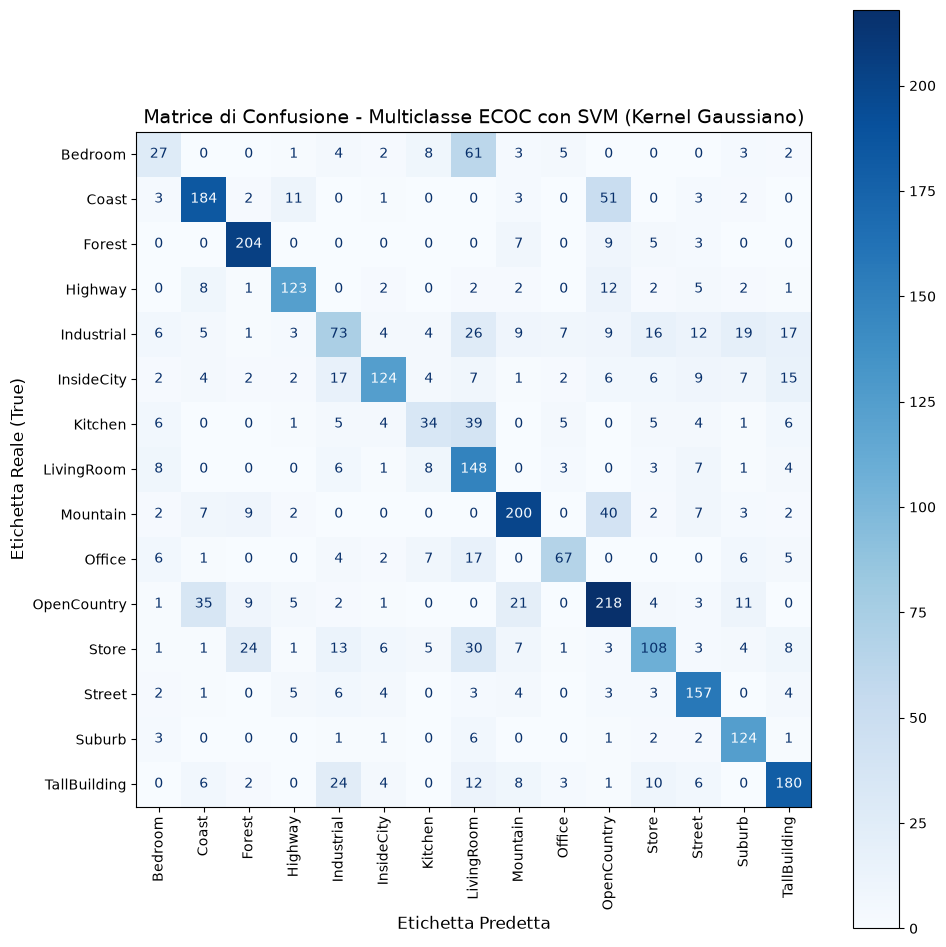

In [34]:
import matplotlib.pyplot as plt

import numpy as np

from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix

from sklearn.multiclass import OutputCodeClassifier

from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
 
# --- 1. CONFIGURAZIONE DEL MODELLO ECOC + SVM GAUSSIANA ---

print(

    "Configurazione del classificatore ECOC con SVM (Kernel Gaussiano/RBF)..."

)
 
# Creiamo la SVM di base con kernel RBF (gaussiano)

base_svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
 
# Creiamo il classificatore ECOC racchiudendo la SVM in una pipeline con lo StandardScaler.

# Lo StandardScaler è essenziale perché le SVM RBF risentono molto della scala delle feature.

ecoc_pipeline = make_pipeline(

    StandardScaler(),

    OutputCodeClassifier(estimator=base_svm, code_size=1.5, random_state=42),

)
 
# --- 2. ADDESTRAMENTO ---

print("Inizio addestramento del modello...")

ecoc_pipeline.fit(X_train, y_train)

print("Addestramento completato con successo!")
 
# --- 3. PREDIZIONE SUL TEST SET ---

print("Esecuzione delle predizioni sul test set...")

y_pred = ecoc_pipeline.predict(X_test)
 
# --- 4. VALUTAZIONE E ACCURATEZZA ---

acc = accuracy_score(y_test, y_pred)

print(f"Accuratezza complessiva del modello ECOC-SVM: {acc * 100:.2f}%")
 
# --- 5. CALCOLO E VISUALIZZAZIONE DELLA MATRICE DI CONFUSIONE ---

# 'classi' deve contenere l'elenco delle etichette uniche (es. ['gatto', 'cane', 'auto', ...])

# Se non hai la lista esatta, puoi estrarla automaticamente con: np.unique(y_test)

if "classi" not in locals() and "classi" not in globals():

  classi = np.unique(y_test)
 
print("Generazione della matrice di confusione...")

cm = confusion_matrix(y_test, y_pred, labels=classi)
 
# Prepariamo la visualizzazione grafica

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classi)
 
# Disegniamo la matrice ruotando le etichette sull'asse x per leggibilità

disp.plot(ax=ax, xticks_rotation="vertical", cmap=plt.cm.Blues)
 
plt.title(

    "Matrice di Confusione - Multiclasse ECOC con SVM (Kernel Gaussiano)",

    fontsize=14,

)

plt.xlabel("Etichetta Predetta", fontsize=12)

plt.ylabel( "Etichetta Reale (True)", fontsize=12)

plt.tight_layout()

plt.show()
 